
# Phân Tích Xu Hướng HYPE Sản Phẩm Bằng Python  
# Mục tiêu: Khám phá, trực quan hóa và dự đoán xu hướng "HYPE" (mức độ quan tâm / doanh thu) của các sản phẩm dựa trên dữ liệu bán hàng thực tế.  
# Các bước phân tích 
1️ Chuẩn bị & tiền xử lý dữ liệu  
2️ Phân tích HYPE tổng thể theo thời gian  
3️ Phân tích HYPE theo sản phẩm  
4️ Phân tích theo khu vực & thời gian trong ngày  
5️ Dự đoán HYPE trong tương lai (Prophet)  
6️ Kết luận & hướng mở rộng  

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('all_sales_data_cleaned.csv')

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df = df.dropna(subset=['Order Date'])
df['Month'] = df['Order Date'].dt.month
df['Hour'] = df['Order Date'].dt.hour
df['Sales'] = df['Quantity Ordered'] * df['Price Each']
df['City'] = df['Purchase Address'].apply(lambda x: x.split(',')[1].strip())

df.head()


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Hour,Sales,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,8,23.90,Dallas
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,22,99.99,Boston
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,14,600.00,Los Angeles
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,14,11.99,Los Angeles
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,9,11.99,Los Angeles


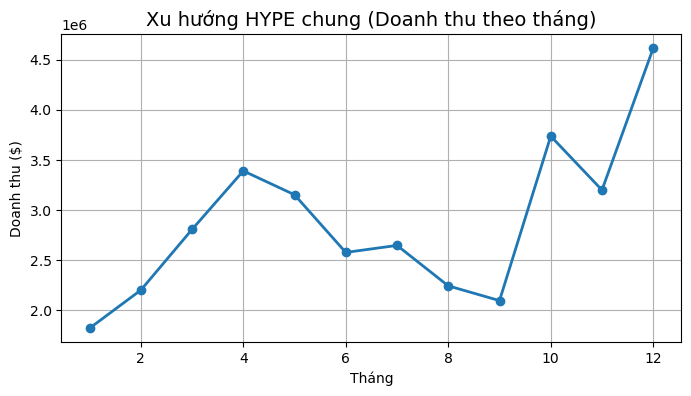

In [2]:

monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

plt.figure(figsize=(8,4))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o', linewidth=2)
plt.title('Xu hướng HYPE chung (Doanh thu theo tháng)', fontsize=14)
plt.xlabel('Tháng')
plt.ylabel('Doanh thu ($)')
plt.grid(True)
plt.show()


<Figure size 1200x600 with 0 Axes>

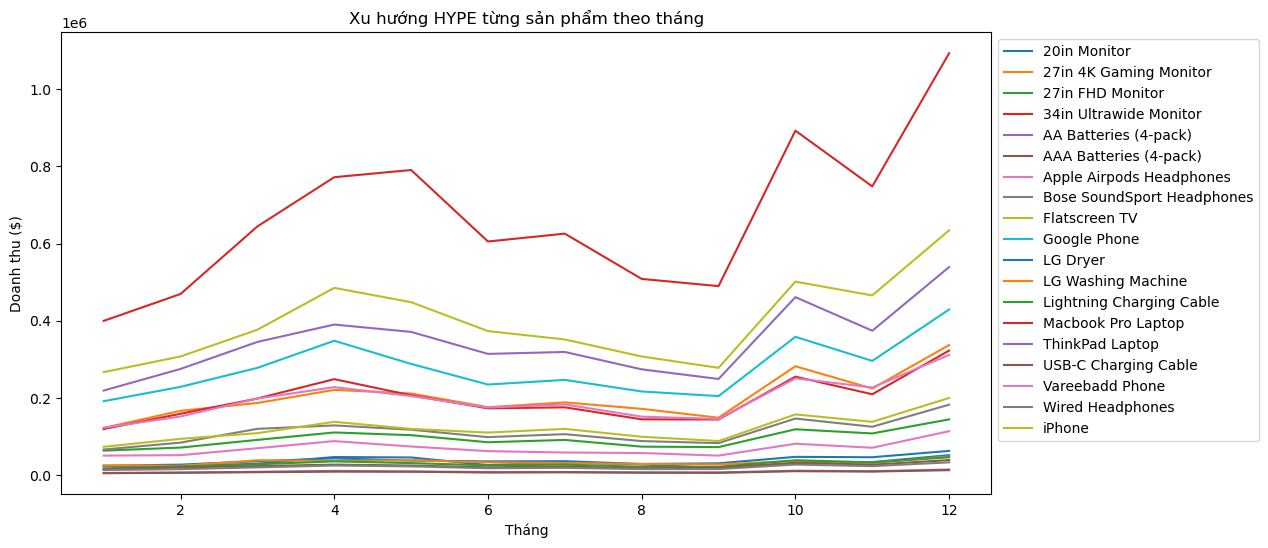

In [3]:

product_trends = df.groupby(['Month', 'Product'])['Sales'].sum().unstack().fillna(0)

plt.figure(figsize=(12,6))
product_trends.plot(figsize=(12,6), linewidth=1.5)
plt.title('Xu hướng HYPE từng sản phẩm theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Doanh thu ($)')
plt.legend(bbox_to_anchor=(1,1))
plt.show()


In [4]:

top_monthly = df.groupby(['Month','Product'])['Sales'].sum().reset_index()
top_per_month = top_monthly.loc[top_monthly.groupby('Month')['Sales'].idxmax()]

print("Top sản phẩm hot nhất từng tháng:")
display(top_per_month)


Top sản phẩm hot nhất từng tháng:


,Month,Product,Sales
13,1,Macbook Pro Laptop,399500.0
32,2,Macbook Pro Laptop,469200.0
51,3,Macbook Pro Laptop,644300.0
70,4,Macbook Pro Laptop,771800.0
89,5,Macbook Pro Laptop,790500.0
108,6,Macbook Pro Laptop,605200.0
127,7,Macbook Pro Laptop,625600.0
146,8,Macbook Pro Laptop,508300.0
165,9,Macbook Pro Laptop,489600.0
184,10,Macbook Pro Laptop,892500.0


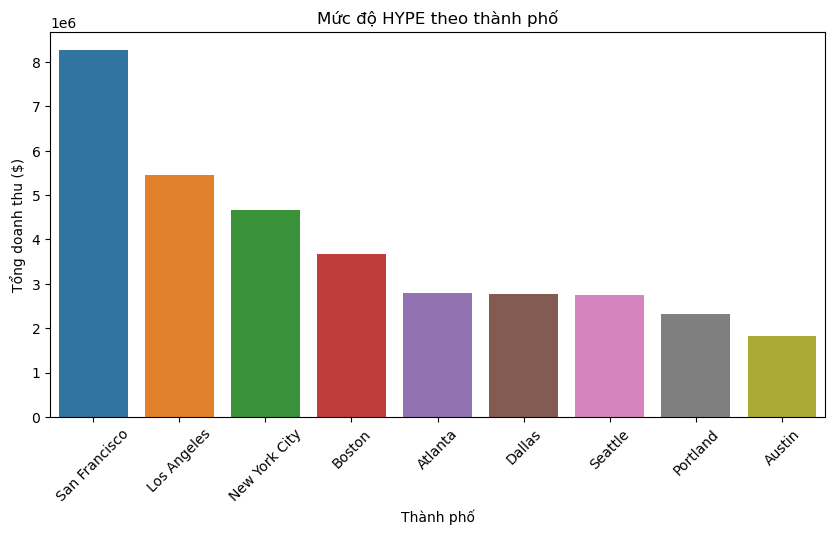

In [5]:

city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=city_sales.index, y=city_sales.values)
plt.title('Mức độ HYPE theo thành phố')
plt.ylabel('Tổng doanh thu ($)')
plt.xlabel('Thành phố')
plt.xticks(rotation=45)
plt.show()


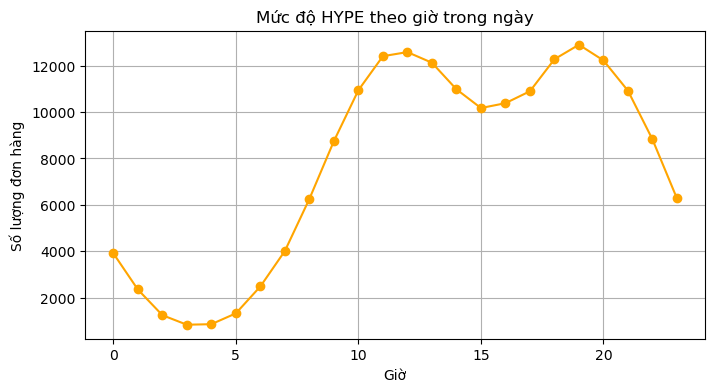

In [6]:

hours = df.groupby('Hour')['Order ID'].count()

plt.figure(figsize=(8,4))
plt.plot(hours.index, hours.values, marker='o', color='orange')
plt.title('Mức độ HYPE theo giờ trong ngày')
plt.xlabel('Giờ')
plt.ylabel('Số lượng đơn hàng')
plt.grid(True)
plt.show()


In [7]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

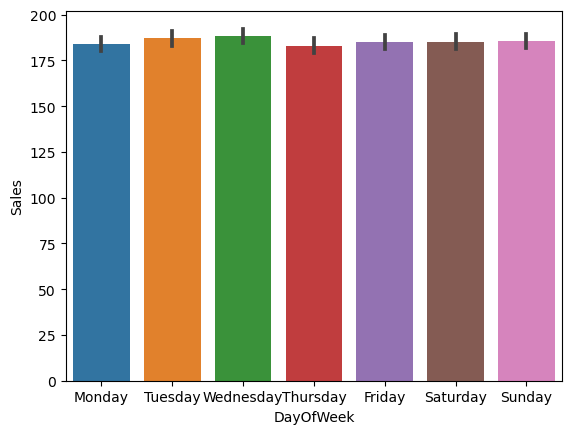

In [8]:
df['DayOfWeek'] = df['Order Date'].dt.day_name()
sns.barplot(data=df, x='DayOfWeek', y='Sales', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

In [9]:
%pip install prophet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


02:21:09 - cmdstanpy - INFO - Chain [1] start processing
02:21:09 - cmdstanpy - INFO - Chain [1] done processing


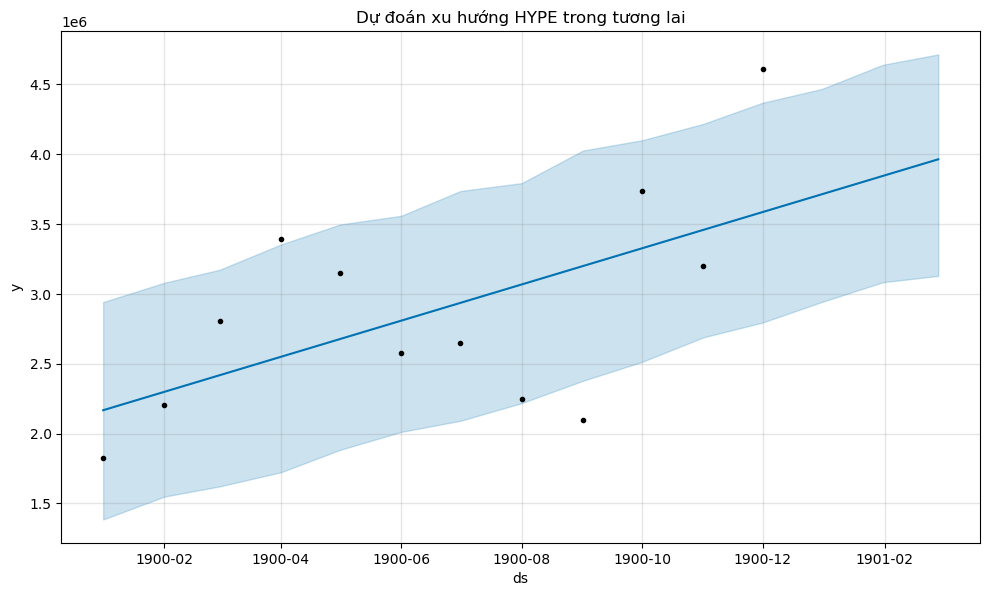

In [11]:
from prophet import Prophet

# Chuẩn bị dữ liệu theo định dạng Prophet
sales_by_month = df.groupby('Month')['Sales'].sum().reset_index()
sales_by_month.columns = ['ds', 'y']
sales_by_month['ds'] = pd.to_datetime(sales_by_month['ds'], format='%m')

# Huấn luyện mô hình
model = Prophet()
model.fit(sales_by_month)

# Tạo dữ liệu dự báo
future = model.make_future_dataframe(periods=3, freq='M')
forecast = model.predict(future)

# Vẽ biểu đồ dự báo
model.plot(forecast)
plt.title('Dự đoán xu hướng HYPE trong tương lai')
plt.show()
